In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa

from pathlib import Path

from grecco_sim.data import simbench_data
from grecco_sim.util.plot import set_two_hours_x_axis

/home/carl-wanninger/anaconda3/envs/grecco_sim/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Topology

In [2]:
data_root = Path("/home/carl-wanninger/data/")

n = pypsa.Network()
 
slack_bus = {"name": "Slack", "v_nom": 10.0}
lv_main_bus = {"name": "LV main bus", "v_nom": 0.4}
bus_p1 = {"name": "Bus Prosumer 1", "v_nom": 0.4}
bus_p2 = {"name": "Bus Prosumer 2", "v_nom": 0.4}

for bus in [slack_bus, lv_main_bus, bus_p1, bus_p2]:
    n.add(class_name="Bus", **bus)

slack_generator = {"name": "ExternalGrid", "bus": "Slack", "control": "Slack"}
n.add(class_name="Generator", **slack_generator)

trafo_type = "0.4 MVA 10/0.4 kV"
bus0, bus1 = slack_bus["name"], lv_main_bus["name"]
transformer = {"name": "MV/LV Transformer", "bus0": bus0, "bus1": bus1, "type": trafo_type}
n.add(class_name="Transformer", **transformer)

line_type = "NAYY 4x150 SE"
length = 0.1  # km
line_1 = {"name": "Feeder 1", "bus0": lv_main_bus["name"], "bus1": bus_p1["name"]}
line_2 = {"name": "Feeder 2", "bus0": lv_main_bus["name"], "bus1": bus_p2["name"]}

for line in [line_1, line_2]:
    n.add(class_name="Line", type=type, length=length, **line)

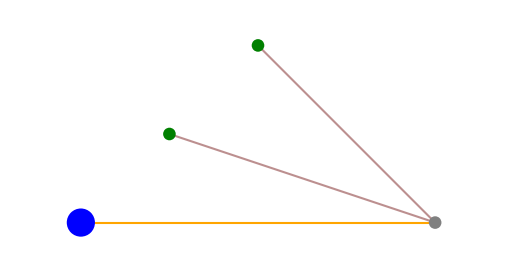

In [3]:
# Validate topology.
# Increase size of MV grid buses and add some colors.
bus_sizes = {b: 0.001 for b in n.buses.index}
bus_colors = {b: "grey" for b in n.buses.index}
bus_sizes["Slack"] = 0.005
bus_colors["Slack"] = "blue"
bus_colors["Bus Prosumer 1"], bus_colors["Bus Prosumer 2"] = "green", "green"

with warnings.catch_warnings(action="ignore"):
    _ = n.plot(bus_colors=bus_colors, bus_sizes=bus_sizes, margin=0.2)

## Timeseries

In [4]:
np.random.seed(65537)

simbench_path = data_root / "simbench_csv" / "all_profiles_2034"
simbench = simbench_data.SimBenchData(simbench_path)
year, month, day = 2016, 10, 12

start = pd.Timestamp(year, month, day)
end = pd.Timestamp(year, month, day + 1)
snapshot_index = pd.date_range(start, end, freq="15min")

n.set_snapshots(snapshot_index)

def filter_timestamps(df: pd.DataFrame, start_time=start, end_time=end):
    return df[(df.index >= start_time) & (df.index < end_time)]

4 duplicates in RESProfile.csv were averaged. 
4 duplicates in LoadProfile.csv were averaged. 
4 duplicates in StorageProfile.csv were averaged. 


In [5]:
# Baseload

# Simbench load profiles are percental timeseries.
baseload_profile_1 = simbench.load_t["H0-A_pload"] * 0.003
baseload_profile_2 = simbench.load_t["H0-B_pload"] * 0.003

baseload_profile_1.index = pd.DatetimeIndex(baseload_profile_1.index)
baseload_profile_2.index = pd.DatetimeIndex(baseload_profile_2.index)

p_baseload_1 = filter_timestamps(baseload_profile_1)
p_baseload_2 = filter_timestamps(baseload_profile_2)
    
load_1 = {"name": "Baseload 1", "bus": bus_p1["name"], "p_set": p_baseload_1}
load_2 = {"name": "Baseload 2", "bus": bus_p2["name"], "p_set": p_baseload_2}

for load in [load_1, load_2]:
    # Carrier information is expected by GrECCo.
    n.add(class_name="Load", carrier="inflex", **load)

In [6]:
# PV
pv_profile_1 = simbench.gen_t["PV1"]
pv_profile_2 = simbench.gen_t["PV2"]

pv_profile_1.index = pd.DatetimeIndex(pv_profile_1.index)
pv_profile_2.index = pd.DatetimeIndex(pv_profile_2.index)

p_pv_1 = filter_timestamps(pv_profile_1) * 0.010
p_pv_2 = filter_timestamps(pv_profile_2) * 0.010

generator_1 = {"name": "PV 1", "bus": bus_p1["name"], "p_set": p_pv_1}
generator_2 = {"name": "PV 2", "bus": bus_p2["name"], "p_set": p_pv_2}

for generator in [generator_1, generator_2]:
    n.add(class_name="Generator", carrier="solar", **generator)

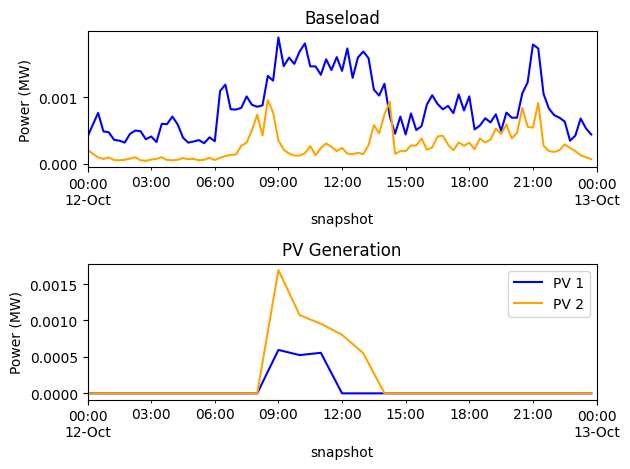

In [7]:
fig, axs = plt.subplots(nrows=2)

for i in range(2):
    axs[i] = set_two_hours_x_axis(axs[i])
    axs[i].set_ylabel("Power (MW)")

label1, label2 = "Baseload 1", "Baseload 2"
axs[0].set_title("Baseload")
n.loads_t["p_set"][label1].plot(ax=axs[0], color="blue", label=label1)
n.loads_t["p_set"][label2].plot(ax=axs[0], color="orange", label=label2)

label1, label2 = "PV 1", "PV 2"
axs[1].set_title("PV Generation")
n.generators_t["p_set"][label1].plot(ax=axs[1], color="blue", label=label1)
n.generators_t["p_set"][label2].plot(ax=axs[1], color="orange", label=label2)

plt.tight_layout()
_ = plt.legend()

In [8]:
# Add Storages

storage_1 = {"name": "Storage 1", "bus": bus_p1["name"], "p_nom": 0.001}
storage_2 = {"name": "Storage 2", "bus": bus_p2["name"], "p_nom": 0.002}

for storage in [storage_1, storage_2]:
    n.add(class_name="StorageUnit", type="h0_battery", **storage)
    

In [9]:
# Add Heat pumps

heat_pump_1 = {"name": "Heat pump 1", "bus": bus_p1["name"], "p_set": 0.002}
heat_pump_2 = {"name": "Heat pump 2", "bus": bus_p2["name"], "p_set": 0.004}

for heat_pump in [heat_pump_1, heat_pump_2]:
    n.add(class_name="Load", carrier="heat_pump", **heat_pump)

In [10]:
# Verify Storages and Heat pumps
n.storage_units_t.keys()
# pd.concat([n.storage_units_t["p_set"], n.storage_units_t["state_of_charge"]], axis=1)
# n.storage_units_t["state_of_charge"]
n.storage_units_t["p_set"]

StorageUnit
snapshot
2016-10-12 00:00:00
2016-10-12 00:15:00
2016-10-12 00:30:00
2016-10-12 00:45:00
2016-10-12 01:00:00
...
2016-10-12 23:00:00
2016-10-12 23:15:00
2016-10-12 23:30:00


In [11]:
# Save grid.
sample_grid_path = data_root / "sample_grids" / "lv_minimal_0"
n.export_to_csv_folder(sample_grid_path, export_standard_types=True)

INFO:pypsa.io:Exported network lv_minimal_0 has transformers, line_types, loads, transformer_types, generators, lines, buses, storage_units


In [12]:
# Simulate Coordination (No coordination / central / fee-based)

In [13]:
# Configuration 0: Baseload

In [14]:
# Configuration 1: Baseload + PV

In [15]:
# Configuration 2: Baseload + Storage

In [16]:
# Configuration 3: Baseload + Heat pump

In [17]:
# Configuration 4: Baseload + PV + Storage

In [18]:
# Configuration 5: Baseload + PV + Heat pump

In [19]:
# Configuration 6: Baseload + Storage + Heat pump

In [20]:
# Configuration 7: Baseload + PV + Storage + Heat pump